# 10-Year Rainfall Daily Feature Compression & HMM Transition Analysis

## Objectives
1. **Compress 10-Year Rainfall Data (4-Gauge Average) into Daily Features**: Aggregate 5-minute spatial average rainfall records across all 4 rain gauges (2000–2009) into 10-year daily statistics (total_rain, max_intensity, rain_fraction).
2. **Average into 1-Year (365-Day) Climatological Features**: Calculate the multi-year daily mean profile across the 365 days of the year, applying a 14-day rolling window to smooth seasonal signals.
3. **Fit Gaussian Hidden Markov Model (GaussianHMM)**: Train a 4-state GaussianHMM on standardized climatological features to identify macro-seasonal regimes.
4. **Observe & Visualize Transition Matrix**: Extract the state transition matrix, analyze state transition dynamics, and render a high-quality heatmap visualization.
5. **Visualize 365-Day Climatological Regimes**: Plot annual rainfall profile colored by hidden state transitions across the year.
6. **Broadcast 365-Day HMM State Sequence to 5-Minute Resolution**: Map the 365-day climatological HMM state sequence (hmm_state column) back to the 10-year 5-minute dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11


## Step 1: Compress 10-Year 5-Minute Data into Daily Features
We load 10 years of 5-minute rainfall data (), set up datetime index, and aggregate into daily statistics for all ~3,650 days.


In [2]:
import glob

# Load all 4 raw 5-minute rainfall gauge datasets
file_paths = sorted(glob.glob('../data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))
print(f"Loading {len(file_paths)} rain gauge datasets:")
for p in file_paths:
    print(f" - {p}")

gauge_dfs = []
for path in file_paths:
    g_df = pd.read_csv(path)
    g_df['datetime'] = pd.to_datetime(g_df['date'] + ' ' + g_df['time'], format='%m/%d/%Y %H:%M:%S')
    g_df.set_index('datetime', inplace=True)
    gauge_dfs.append(g_df['rainfall_intensity'])

# Combine and compute 4-gauge average 5-minute rainfall intensity
df_5min = pd.concat(gauge_dfs, axis=1).mean(axis=1).to_frame(name='rainfall_intensity').reset_index()

# Keep datetime index for daily resampling
df = df_5min.set_index('datetime')

# Resample 4-gauge average series to Daily Features across 10 Years
daily_10yr = pd.DataFrame({
    'total_rain': df['rainfall_intensity'].resample('D').sum(),
    'max_intensity': df['rainfall_intensity'].resample('D').max(),
    'rain_fraction': (df['rainfall_intensity'] > 0).astype(int).resample('D').mean(),
}).reset_index()

daily_10yr['year'] = daily_10yr['datetime'].dt.year
daily_10yr['day_of_year'] = daily_10yr['datetime'].dt.dayofyear

# Filter out leap year day 366 for consistent 365-day annual alignment
daily_10yr = daily_10yr[daily_10yr['day_of_year'] <= 365].copy()

print(f"Compressed 10-Year Daily Dataset (4-Gauge Avg) Shape: {daily_10yr.shape}")
daily_10yr.head()


Loading 4 rain gauge datasets:
 - ../data/rainfall/astlingen/1Astlingen_Erft1.csv
 - ../data/rainfall/astlingen/2Astlingen_Erft2.csv
 - ../data/rainfall/astlingen/3Astlingen_Erft3.csv
 - ../data/rainfall/astlingen/4Astlingen_Erft4.csv
Compressed 10-Year Daily Dataset (4-Gauge Avg) Shape: (3650, 6)


,datetime,total_rain,max_intensity,rain_fraction,year,day_of_year
0,2000-01-01,1.7525,0.0850,0.215278,2000,1
1,2000-01-02,5.1325,0.2100,0.333333,2000,2
2,2000-01-03,1.9325,0.2850,0.100694,2000,3
3,2000-01-04,6.1850,0.1575,0.309028,2000,4
4,2000-01-05,0.0350,0.0175,0.010417,2000,5


## Step 2: Average 10-Year Daily Features into 1-Year (365-Day) Climatological Features
We group by  (1–365), calculate the 10-year mean for each day, and apply a 14-day rolling mean filter to smooth high-frequency day-to-day noise into continuous seasonal signals.


In [3]:
# Average across 10 years by day of year
clim_365 = daily_10yr.groupby('day_of_year')[['total_rain', 'max_intensity', 'rain_fraction']].mean()

# Apply 14-day rolling window for climatological smoothing
clim_smooth = clim_365.rolling(window=14, min_periods=1, center=True).mean()

print(f"1-Year (365-Day) Climatological Feature Shape: {clim_smooth.shape}")
clim_smooth.head()


1-Year (365-Day) Climatological Feature Shape: (365, 3)


,total_rain,max_intensity,rain_fraction
day_of_year,,,
1,2.362643,0.160643,0.119097
2,2.343719,0.157313,0.118837
3,2.358556,0.151639,0.123534
4,2.443975,0.152425,0.130521
5,2.446773,0.150432,0.134028


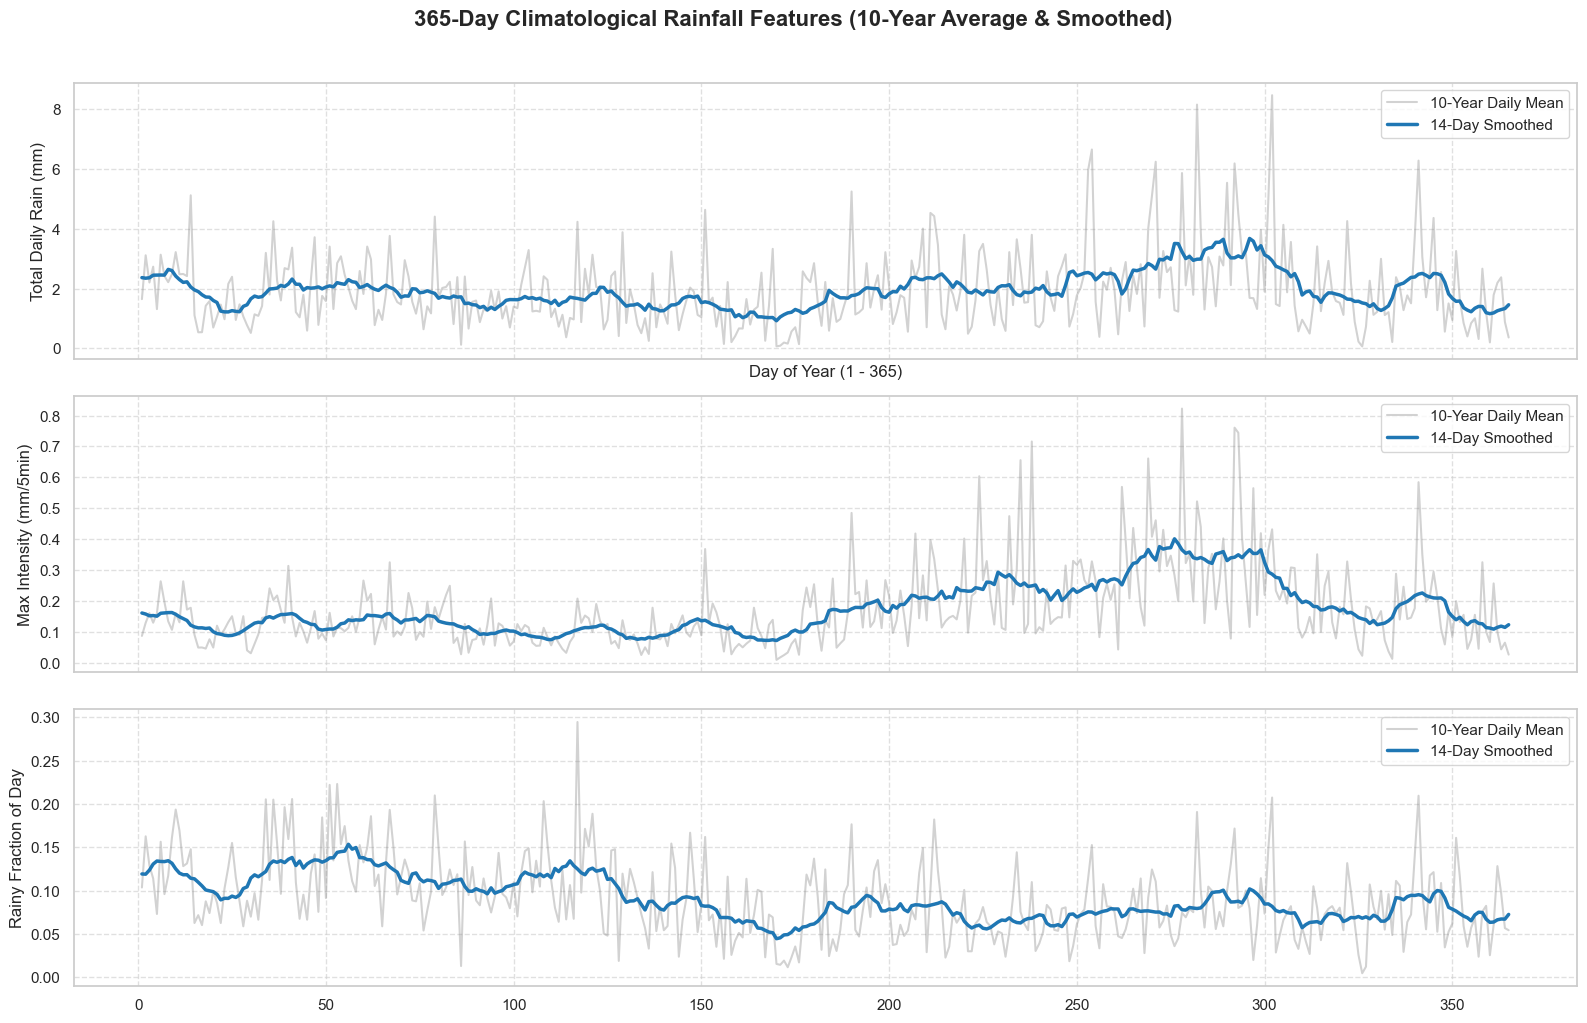

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

metrics = [('total_rain', 'Total Daily Rain (mm)'),
           ('max_intensity', 'Max Intensity (mm/5min)'),
           ('rain_fraction', 'Rainy Fraction of Day')]

for ax, (col, label) in zip(axes.flatten(), metrics):
    ax.plot(clim_365.index, clim_365[col], alpha=0.35, color='gray', label='10-Year Daily Mean')
    ax.plot(clim_smooth.index, clim_smooth[col], color='#1f77b4', linewidth=2.5, label='14-Day Smoothed')
    ax.set_ylabel(label, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')

axes[0].set_xlabel('Day of Year (1 - 365)', fontsize=12)
fig.suptitle('365-Day Climatological Rainfall Features (10-Year Average & Smoothed)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Step 3: Fit Hidden Markov Model (GaussianHMM)
We standardize the 365-day climatological daily features and fit a 4-state  to detect discrete meteorological regimes.


In [5]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clim_smooth[['total_rain', 'max_intensity', 'rain_fraction']])

# Fit Gaussian HMM with 4 states
n_states = 4
hmm_model = hmm.GaussianHMM(n_components=n_states, covariance_type='full', n_iter=200, random_state=42)

# This line runs the Viterbi algorithm under the hood
hmm_model.fit(X_scaled)

# Predict hidden states for the 365 days
states = hmm_model.predict(X_scaled)
clim_smooth['hmm_state'] = states

# Sort state labels by mean total_rain to ensure intuitive state ordering (State 0 = Lowest Rain, State 3 = Highest Rain)
state_means = clim_smooth.groupby('hmm_state')['total_rain'].mean().sort_values()
state_mapping = {old_st: new_st for new_st, old_st in enumerate(state_means.index)}

# Re-map states and transition matrix
clim_smooth['hmm_state'] = clim_smooth['hmm_state'].map(state_mapping)

transmat_raw = hmm_model.transmat_
transmat_ordered = np.zeros_like(transmat_raw)
for old_i, new_i in state_mapping.items():
    for old_j, new_j in state_mapping.items():
        transmat_ordered[new_i, new_j] = transmat_raw[old_i, old_j]

print("HMM Fitting Complete!")
print(f"Re-ordered State Means (Total Daily Rain mm):{clim_smooth.groupby('hmm_state')['total_rain'].mean()}")


HMM Fitting Complete!
Re-ordered State Means (Total Daily Rain mm):hmm_state
0    1.432796
1    1.840816
2    2.106473
3    2.551865
Name: total_rain, dtype: float64


## Step 4: Observe & Visualize Transition Matrix
The transition probability matrix {ij} = P(S_{t+1} = j \mid S_t = i)$ governs how the rainfall regime transitions from day $ to day +1$.


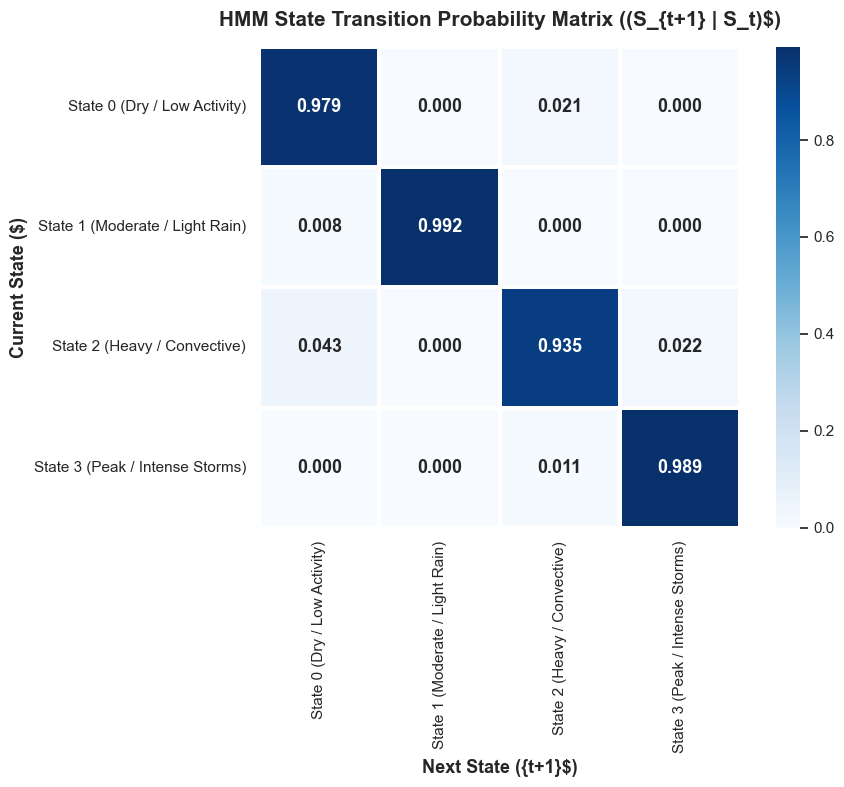

In [6]:
state_names = [
    f'State 0 (Dry / Low Activity)',
    f'State 1 (Moderate / Light Rain)',
    f'State 2 (Heavy / Convective)',
    f'State 3 (Peak / Intense Storms)'
]

trans_df = pd.DataFrame(transmat_ordered, index=state_names, columns=state_names)

plt.figure(figsize=(10, 8))
sns.heatmap(trans_df, annot=True, fmt='.3f', cmap='Blues', cbar=True,
            linewidths=1.5, square=True, annot_kws={'size': 13, 'weight': 'bold'})
plt.title('HMM State Transition Probability Matrix ((S_{t+1} | S_t)$)', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Current State ($)', fontsize=13, fontweight='bold')
plt.xlabel('Next State ({t+1}$)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 5: Visualize 365-Day Climatological Regimes & State Transitions
We plot the 365-day climatological daily features overlaid with background shading corresponding to the HMM state sequence across the year.


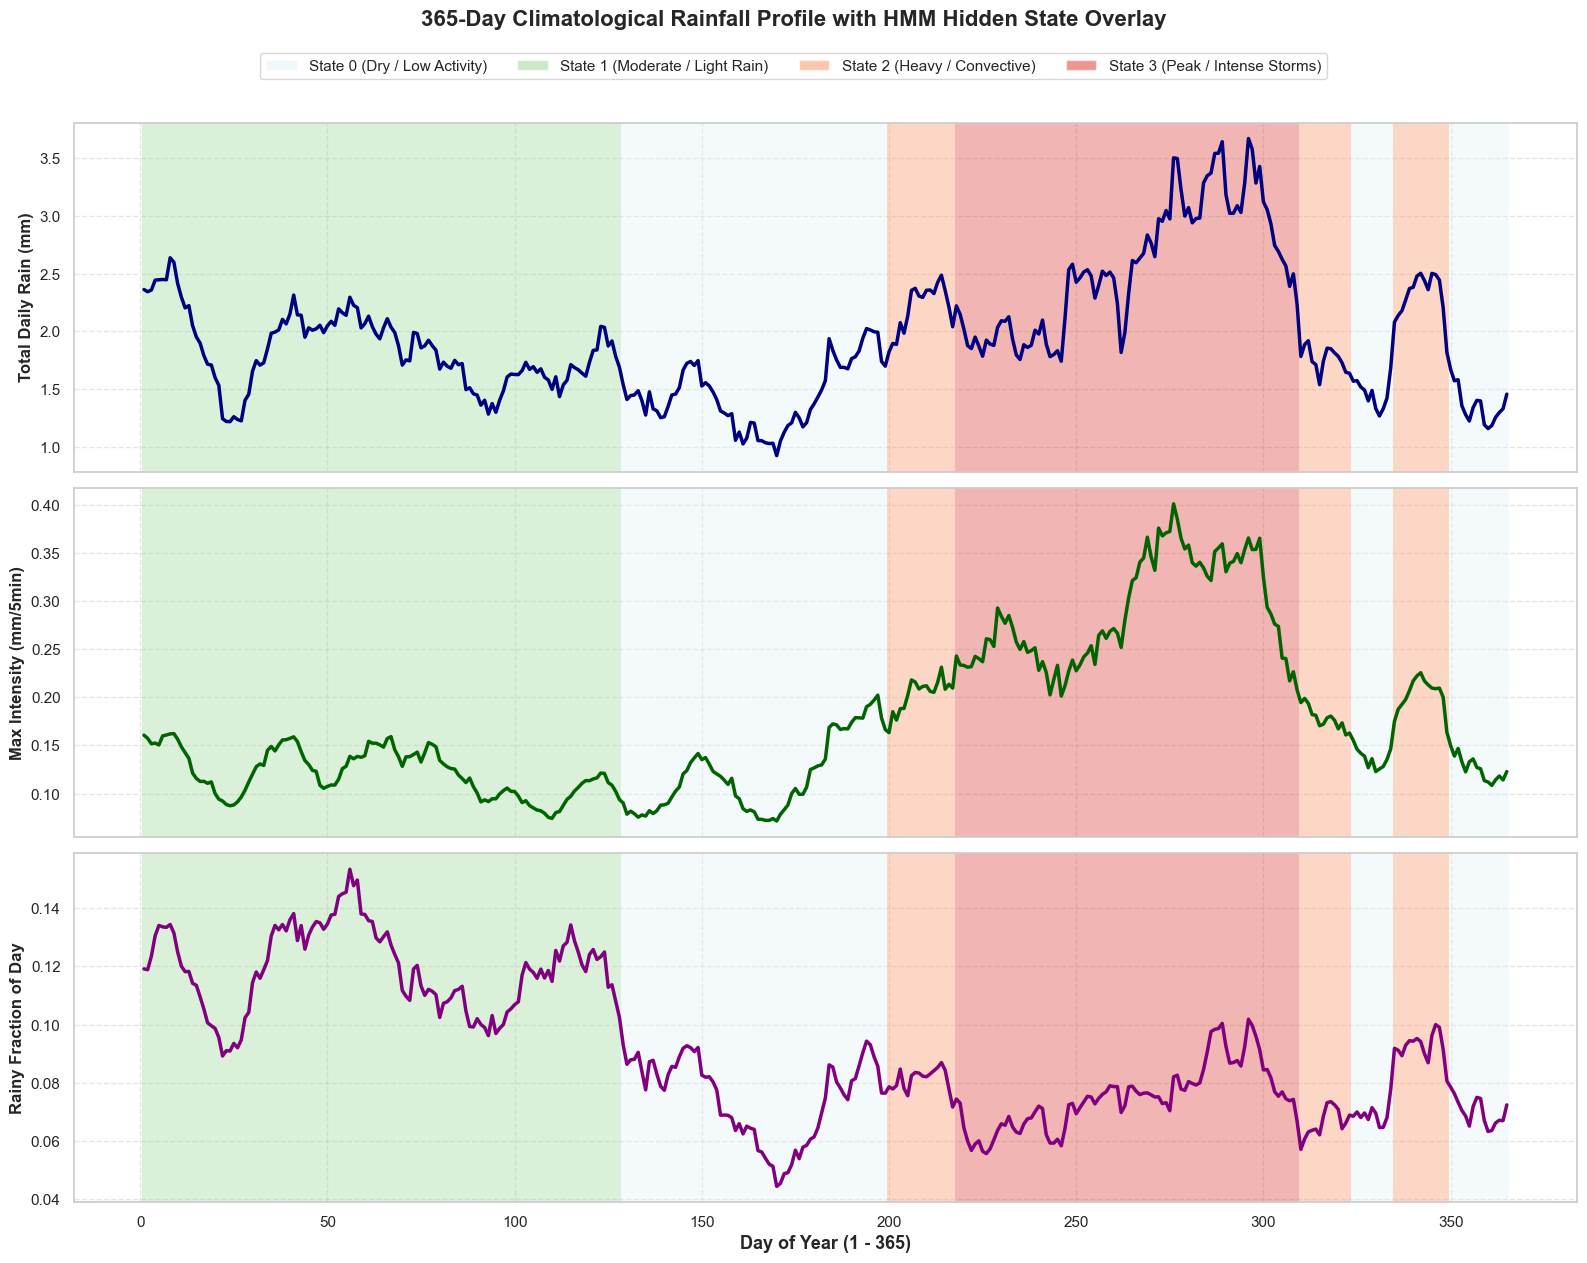

In [7]:
colors = ['#e0f3f8', '#99d594', '#fc8d59', '#d73027']

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# 1. Total Rain
axes[0].plot(clim_smooth.index, clim_smooth['total_rain'], color='navy', linewidth=2.5, label='Total Rain (mm)')
axes[0].set_ylabel('Total Daily Rain (mm)', fontsize=12, fontweight='bold')

# 2. Max Intensity
axes[1].plot(clim_smooth.index, clim_smooth['max_intensity'], color='darkgreen', linewidth=2.5, label='Max Intensity (mm/5min)')
axes[1].set_ylabel('Max Intensity (mm/5min)', fontsize=12, fontweight='bold')

# 3. Rain Fraction
axes[2].plot(clim_smooth.index, clim_smooth['rain_fraction'], color='purple', linewidth=2.5, label='Rain Fraction')
axes[2].set_ylabel('Rainy Fraction of Day', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Day of Year (1 - 365)', fontsize=13, fontweight='bold')

# Apply background shading for HMM states
for ax in axes:
    for day in range(1, 366):
        st = clim_smooth.loc[day, 'hmm_state']
        ax.axvspan(day - 0.5, day + 0.5, color=colors[st], alpha=0.35, linewidth=0)
    ax.grid(True, linestyle='--', alpha=0.5)

# Custom legend for HMM states
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.5, label=state_names[i]) for i in range(4)]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=4, fontsize=11, frameon=True)

plt.suptitle('365-Day Climatological Rainfall Profile with HMM Hidden State Overlay', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## Step 6: HMM Regime Characterization Summary
Summary statistics of climatological daily features across each learned HMM state.


In [8]:
summary_df = clim_smooth.groupby('hmm_state')[['total_rain', 'max_intensity', 'rain_fraction']].mean()
summary_df['Days_in_Year'] = clim_smooth.groupby('hmm_state').size()
summary_df.index = state_names
summary_df

,total_rain,max_intensity,rain_fraction,Days_in_Year
State 0 (Dry / Low Activity),1.432796,0.121055,0.073143,98
State 1 (Moderate / Light Rain),1.840816,0.121536,0.118829,128
State 2 (Heavy / Convective),2.106473,0.195652,0.080347,47
State 3 (Peak / Intense Storms),2.551865,0.288567,0.075028,92


## Step 7: Broadcast 365-Day HMM State Sequence to 5-Minute Dataset
We map the 365-day climatological HMM state sequence (`hmm_state` 0–3) back to each 5-minute record in the 10-year 4-gauge average dataset based on `day_of_year`.


In [9]:
# Create mapping from day_of_year (1-365) to HMM state
state_map = clim_smooth['hmm_state'].to_dict()

# Extract date, time, and day_of_year for 5-minute dataset
df_5min['date'] = df_5min['datetime'].dt.strftime('%d/%m/%Y')
df_5min['time'] = df_5min['datetime'].dt.strftime('%H:%M:%S')
df_5min['day_of_year'] = df_5min['datetime'].dt.dayofyear

# Broadcast 365-day HMM state to 5-minute resolution
# Handle leap-year day 366 by falling back to day 365 state
df_5min['hmm_state'] = df_5min['day_of_year'].map(state_map).fillna(state_map[365]).astype(int)

print("Broadcasting HMM State Sequence Complete!")
print(f"5-Minute Labeled Dataset Shape: {df_5min.shape}")
print("\nDistribution of HMM States in 5-Minute Dataset:")
print(df_5min['hmm_state'].value_counts().sort_index())

# Save the broadcasted 5-minute dataset with hmm_state column
output_csv = '../data/rainfall/astlingen/Astlingen_Erft_5min_averaged_HMM.csv'
df_5min[['date', 'time', 'rainfall_intensity', 'hmm_state']].to_csv(output_csv, index=False)
print(f"Saved 5-minute averaged dataset with HMM states to: {output_csv}")

df_5min[['datetime', 'date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].head(10)


Broadcasting HMM State Sequence Complete!
5-Minute Labeled Dataset Shape: (1051200, 6)

Distribution of HMM States in 5-Minute Dataset:
hmm_state
0    283104
1    367776
2    135360
3    264960
Name: count, dtype: int64
Saved 5-minute averaged dataset with HMM states to: ../data/rainfall/astlingen/Astlingen_Erft_5min_averaged_HMM.csv


,datetime,date,time,rainfall_intensity,day_of_year,hmm_state
0,2000-01-01 00:00:00,01/01/2000,00:00:00,0.005,1,1
1,2000-01-01 00:05:00,01/01/2000,00:05:00,0.000,1,1
2,2000-01-01 00:10:00,01/01/2000,00:10:00,0.000,1,1
3,2000-01-01 00:15:00,01/01/2000,00:15:00,0.000,1,1
4,2000-01-01 00:20:00,01/01/2000,00:20:00,0.000,1,1
5,2000-01-01 00:25:00,01/01/2000,00:25:00,0.000,1,1
6,2000-01-01 00:30:00,01/01/2000,00:30:00,0.015,1,1
7,2000-01-01 00:35:00,01/01/2000,00:35:00,0.035,1,1
8,2000-01-01 00:40:00,01/01/2000,00:40:00,0.010,1,1
9,2000-01-01 00:45:00,01/01/2000,00:45:00,0.010,1,1


## Step 8: Visualize 5-Minute Time Series Sample with Broadcasted HMM States
Plot a sample 14-day window of 5-minute rainfall intensity overlaying the broadcasted HMM state background shading.


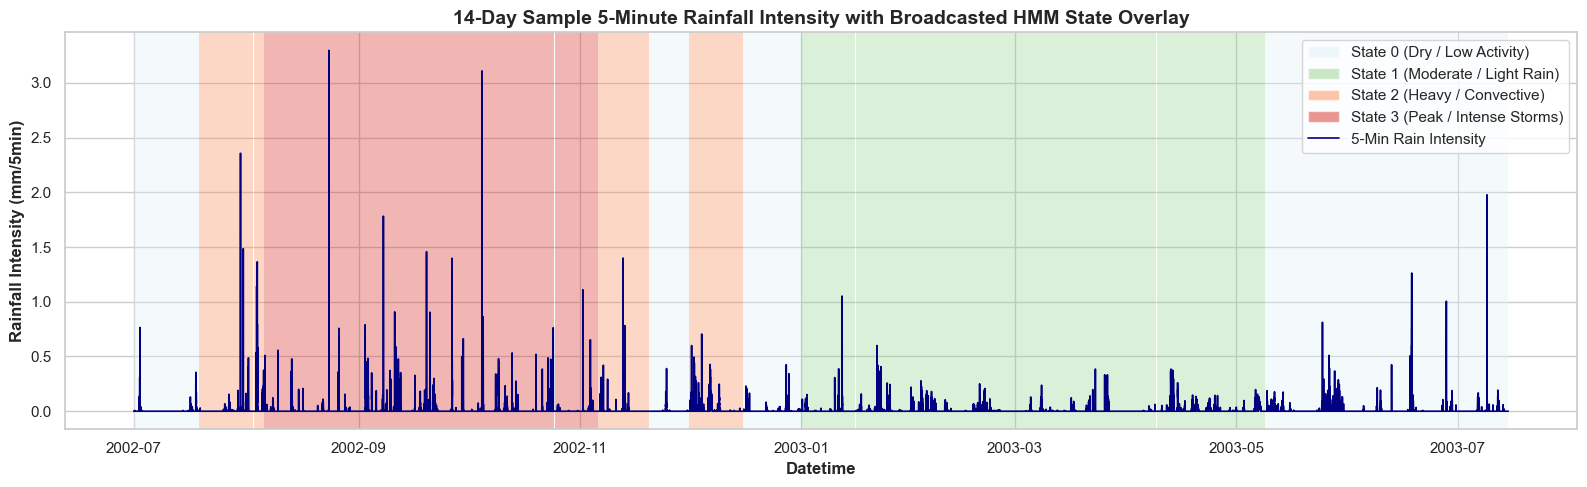

In [13]:
# Visualize a 14-day sample window (e.g. July 1 to July 15, 2000)
sample_mask = (df_5min['datetime'] >= '2002-07-01') & (df_5min['datetime'] <= '2003-07-15')
sample_df = df_5min[sample_mask].copy()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample_df['datetime'], sample_df['rainfall_intensity'], color='navy', linewidth=1.2, label='5-Min Rain Intensity (4-Gauge Avg)')
ax.set_ylabel('Rainfall Intensity (mm/5min)', fontsize=12, fontweight='bold')
ax.set_xlabel('Datetime', fontsize=12, fontweight='bold')
ax.set_title('14-Day Sample 5-Minute Rainfall Intensity with Broadcasted HMM State Overlay', fontsize=14, fontweight='bold')

# Background shading for HMM states using daily grouping for performance
sample_df['day_floor'] = sample_df['datetime'].dt.floor('D')
for d, group in sample_df.groupby('day_floor'):
    st = group['hmm_state'].iloc[0]
    t_start = group['datetime'].iloc[0]
    t_end = group['datetime'].iloc[-1]
    ax.axvspan(t_start, t_end, color=colors[st], alpha=0.35, linewidth=0)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.5, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='navy', lw=1.2, label='5-Min Rain Intensity'))
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


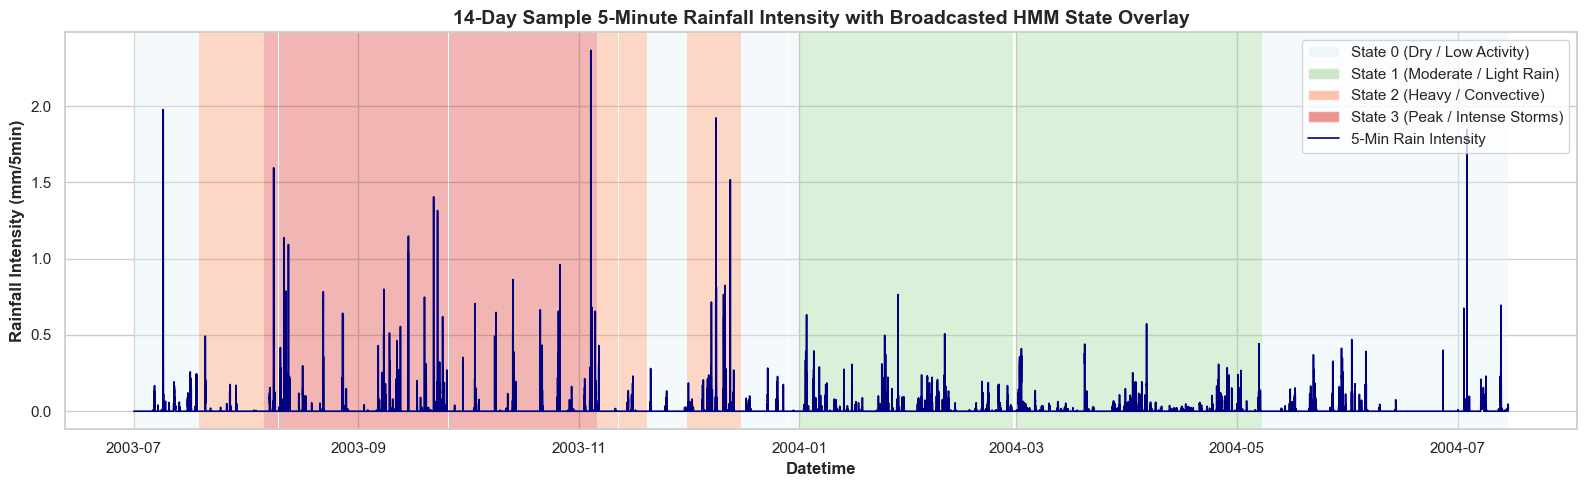

In [14]:
# Visualize a 14-day sample window (e.g. July 1 to July 15, 2000)
sample_mask = (df_5min['datetime'] >= '2003-07-01') & (df_5min['datetime'] <= '2004-07-15')
sample_df = df_5min[sample_mask].copy()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample_df['datetime'], sample_df['rainfall_intensity'], color='navy', linewidth=1.2, label='5-Min Rain Intensity (4-Gauge Avg)')
ax.set_ylabel('Rainfall Intensity (mm/5min)', fontsize=12, fontweight='bold')
ax.set_xlabel('Datetime', fontsize=12, fontweight='bold')
ax.set_title('14-Day Sample 5-Minute Rainfall Intensity with Broadcasted HMM State Overlay', fontsize=14, fontweight='bold')

# Background shading for HMM states using daily grouping for performance
sample_df['day_floor'] = sample_df['datetime'].dt.floor('D')
for d, group in sample_df.groupby('day_floor'):
    st = group['hmm_state'].iloc[0]
    t_start = group['datetime'].iloc[0]
    t_end = group['datetime'].iloc[-1]
    ax.axvspan(t_start, t_end, color=colors[st], alpha=0.35, linewidth=0)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.5, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='navy', lw=1.2, label='5-Min Rain Intensity'))
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

In [19]:
import os

# ==========================================
# 2. Setup Dedicated Output Directory
# ==========================================
output_dir = '../data/rainfall/astlingen/hmm_datasets'
os.makedirs(output_dir, exist_ok=True)

# Generate Systematic Filename
filename = "dataset_with_365_fit_hmm.csv"
output_csv_path = os.path.join(output_dir, filename)

# ==========================================
# 3. Broadcast HMM States & Format Columns
# ==========================================
# Map 365-day HMM state sequence to 5-minute dataset
state_map = clim_smooth['hmm_state'].to_dict()

df_5min['date'] = df_5min['datetime'].dt.strftime('%d/%m/%Y')
df_5min['time'] = df_5min['datetime'].dt.strftime('%H:%M:%S')
df_5min['day_of_year'] = df_5min['datetime'].dt.dayofyear

# Broadcast state (fallback to day 365 for leap-year day 366)
df_5min['hmm_state'] = df_5min['day_of_year'].map(state_map).fillna(state_map[365]).astype(int)

# Select and order output columns
export_cols = ['date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']

# ==========================================
# 4. Save to CSV
# ==========================================
df_5min[export_cols].to_csv(output_csv_path, index=False)

print(f"Successfully saved broadcasted dataset ({df_5min.shape[0]:,} rows) to:")
print(f"  --> {output_csv_path}")


Successfully saved broadcasted dataset (1,051,200 rows) to:
  --> ../data/rainfall/astlingen/hmm_datasets/dataset_with_365_fit_hmm.csv
